# Exploring Franka Panda

Let's take a first look at the Franka Panda robot.

In [17]:
import time
import numpy as np
import robosuite as suite

## Instantiate the Environment

Here we will reuse the pre-made environment where Panda tries to lift a cube from a table. Robosuite ships everything ready-made, hence don't worry about the setup. The environment is named = Lift.

In [18]:
env = suite.make(
    env_name = "Lift",
    robots = "Panda",
    has_renderer=True, # used to show mujoco renderer
    has_offscreen_renderer=True,
)

[robosuite INFO] Loading controller configuration from: c:\Users\soham\miniconda3\envs\robo\lib\site-packages\robosuite\controllers\config\robots\default_panda.json (composite_controller_factory.py:121)


## Observation dictionary

This is like a MDP type environment. After every action taken, the robot implements that action and the environment gives us back the observation, reward, done status, and then some more supplemental information. 

The "done" state is a binary variable - which tells us whether the task at hand is complete. Has values "success" or "failure".

In [19]:
obs = env.reset() # reset: literally resets the environment to the initial/random state and returns an observation

[robosuite INFO] Loading controller configuration from: c:\Users\soham\miniconda3\envs\robo\lib\site-packages\robosuite\controllers\config\robots\default_panda.json (composite_controller_factory.py:121)


Lets look at what the observation dictionary gives us back:

In [20]:
for k, v in obs.items():
    print(f" {k:30s} shape = {np.shape(v)}")

 robot0_joint_pos               shape = (7,)
 robot0_joint_pos_cos           shape = (7,)
 robot0_joint_pos_sin           shape = (7,)
 robot0_joint_vel               shape = (7,)
 robot0_joint_acc               shape = (7,)
 robot0_eef_pos                 shape = (3,)
 robot0_eef_quat                shape = (4,)
 robot0_eef_quat_site           shape = (4,)
 robot0_gripper_qpos            shape = (2,)
 robot0_gripper_qvel            shape = (2,)
 agentview_image                shape = (256, 256, 3)
 cube_pos                       shape = (3,)
 cube_quat                      shape = (4,)
 gripper_to_cube_pos            shape = (3,)
 robot0_proprio-state           shape = (50,)
 object-state                   shape = (10,)


## Action Space

Let's look at how many actions are avaialble, and what are the upper and lower bounds in the action space. Intuitively, we know that there will be 7 actions - each corresponding to moving each of the 6 arms of the Panda, and the last one for the end effector. 

We will look at individual actions later on.

In [21]:
print(" Action Dimension = ", env.action_dim)
print(" Action Bounds Low = ", env.action_spec[0])
print(" Action Bounds High = ", env.action_spec[1])

 Action Dimension =  7
 Action Bounds Low =  [-1. -1. -1. -1. -1. -1. -1.]
 Action Bounds High =  [1. 1. 1. 1. 1. 1. 1.]


## Lets Simulate

1. Simulate for N timesteps. N = 200
2. Note that mujoco runs on 2 clocks: the controller computes a control action once every timestep
3. The physics engine propagates the model through 25 time steps within a single timestep
4. Hence the physics engine timestep is 25 times smaller
5. We generate random actions for demonstration. 
6. After the environment takes a step with an action; it gives back the observation dict, reward, done status and some additional information. 
7. `env.render()` renders the motion in mujoco.

In [27]:
# Start a sim and store the results

observations, rewards, dones, infos = [], [], [], []

for i in range(200): 
    action = np.random.randn(env.action_dim)
    obs, reward, done, info = env.step(action)

    observations.append(obs)
    rewards.append(reward)
    dones.append(done)
    infos.append(info)

    env.render()
    if done:
        break

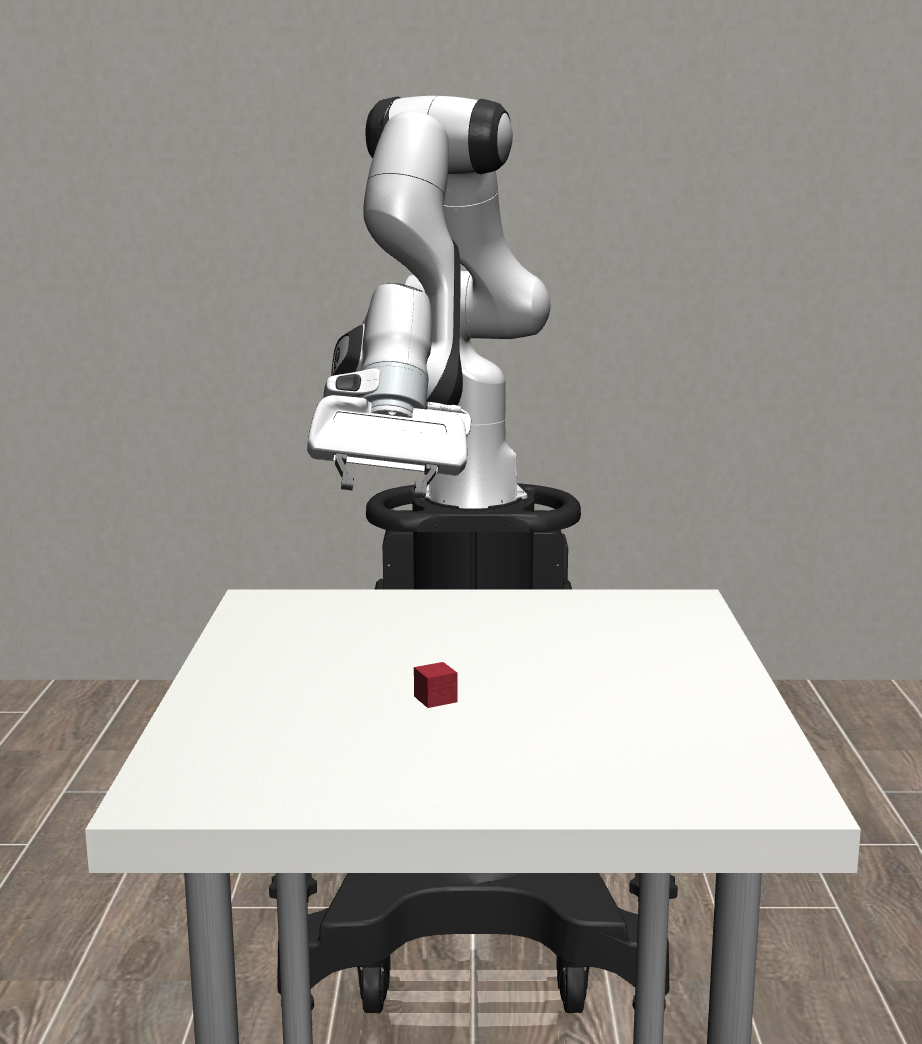

Lets look at what `done` and `info` looks like: 

1. In this environment, done means the robot successfully lifted the cube

Since the cube wasn't lifted the done status is always False

In [28]:
print(dones)

[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False

Since we did not configure "info" the field is left blank by robosuite

In [29]:
print(infos)

[{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}]
